## Esta es la actualizacion del Modelo 3

# Bloque Transformer: Integración de Single-Head Attention y Conexiones Residuales

En esta iteración del modelo, la actualización central es la integración de una **subcapa de atención autorregresiva (Single-Head Attention)** dentro del flujo de procesamiento de los embeddings.

---

## 1. El Flujo de Datos en el Modelo

El recorrido de la información desde el texto crudo hasta la predicción final sigue esta secuencia:

1. **Tokenización:** Conversión del texto en una secuencia de identificadores enteros (`input_ids`).
2. **Embeddings Iniciales:** Suma de los **Token Embeddings** y los **Positional Embeddings** ($X = X_{\text{tok}} + X_{\text{pos}}$).
3. **Bloque Transformer (Actualización actual):** Procesamiento contextual mediante normalización, autoatención y conexiones residuales.
4. **LayerNorm Final y Unembedding:** Proyección lineal final de vuelta a la dimensión del vocabulario para obtener los logits y predecir el siguiente token.

---

## 2. Single-Head Attention vs. Multi-Head y la Matriz $W_O$

* **En Multi-Head Attention (MHA):** Los embeddings se dividen (*split*) en múltiples subespacios que procesan diferentes relaciones semánticas en paralelo. Al final, las salidas de todas las cabezas se concatenan y se multiplican por una matriz de proyección final **$W_O$** para mezclar linealmente la información y devolverla a la dimensión original $d_{\text{model}}$.
* **En Single-Head Attention:** La ecuación de atención opera directamente sobre la dimensionalidad completa ($d_{\text{model}} \times d_{\text{model}}$) en una sola cabeza, procesando el contexto completo sin requerir divisiones intermedias.

---

## 3. Conexiones Residuales (*Skip Connections*): ¿Por qué conservar una copia?

El flujo interno de la subcapa de atención sigue la estructura **Pre-LN con conexión residual**:

$$\text{Salida} = X + \text{Attention}(\text{LayerNorm}(X))$$

### ¿Por qué sumamos el resultado al vector original en lugar de reemplazarlo?

* **Ajustes incrementales, no reemplazo:** La subcapa de atención no intenta inventar un vector completamente nuevo desde cero. Su objetivo es calcular **pequeños ajustes contextuales** (rotaciones o escalados finos en el espacio latente) sobre la información que el token ya posee.
* **El *Residual Stream*:** El vector original actúa como una «autopista de información» que transporta la identidad del token a lo largo de toda la red, permitiendo que cada bloque solo añada el contexto que considere relevante.
* **Flujo de gradientes:** Esta suma previene el desvanecimiento del gradiente (*vanishing gradients*), facilitando el entrenamiento de arquitecturas profundas.

---

## 4. Anatomía de un Bloque Transformer Completo

Un **Transformer Block** estándar consta de dos subcapas principales:

1. **Subcapa de Atención:** Mecanismo de autoatención causal con normalización previa y conexión residual.
2. **Subcapa MLP (Feed-Forward Network):** Dos transformaciones lineales con una activación no lineal intermedia (como GELU), encargada de procesar y refinar las características individuales de cada token *(simplificada o reservada para iteraciones posteriores)*.

---

## 5. Apilado de Bloques (*Stacking*)

El poder representacional de los LLMs proviene de apilar estos bloques idénticos uno encima de otro:

* **GPT-2 Small:** Apila **12 bloques Transformer** consecutivos ($d_{\text{model}} = 768$, 12 cabezas).
* **Modelos de gran escala:** Escalan este principio apilando desde decenas hasta más de un centenar de bloques sucesivos, donde cada capa refina progresivamente el nivel de abstracción del texto.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# pytorch Librerias
import torch
import torch.nn as nn
from torch.nn import functional as F

In [2]:
# Cargar tokenizador GPT-2 en lugar del tokenizador GPT-4
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## Hyperparametros

In [3]:
# Hiperparámetros de datos
seq_len = 8  # también conocido como ventana de contexto (context window / seq_len)

n_vocab = tokenizer.vocab_size  # tamaño del vocabulario

# Hiperparámetros del modelo
embed_dim = 2**6  # 64

# Hiperparámetros de entrenamiento
batch_size = 5

## El modelo

In [4]:
class Model(nn.Module):

  def __init__(self):
    super().__init__()

    # Matrices de embeddings
    self.embedding = nn.Embedding(n_vocab, embed_dim)
    self.positions = nn.Embedding(seq_len, embed_dim)

    # Capa lineal de salida final (des-embeddings / unembeddings)
    self.finalLinear = nn.Linear(embed_dim, n_vocab, bias=False)

    # Inicializar las matrices k, q, v para atención
    self.layernormA = nn.LayerNorm(embed_dim)
    self.key = nn.Linear(embed_dim, embed_dim, bias=False)
    self.query = nn.Linear(embed_dim, embed_dim, bias=False)
    self.value = nn.Linear(embed_dim, embed_dim, bias=False)
    self.W0 = nn.Linear(embed_dim, embed_dim)

    # La capa de salida final comparte pesos con el embedding de tokens (weight tying)
    self.finalLinear.weight = nn.Parameter(self.embedding.weight)

  def forward(self, tokx):

    # Crear el embedding de token + posición
    token_embed = self.embedding(tokx)
    posit_embed = self.positions(
        torch.arange(tokx.shape[-1])
    )  # [numtokens, embedding_dims]

    # Su suma es la salida de los embeddings (la suma hace broadcast para batch > 1)
    x = token_embed + posit_embed  # [batch, numtokens, embedding_dims]

    # --- Comienza la subcapa de atención
    # LayerNorm antes de la atención
    x = self.layernormA(x)

    # Algoritmo de atención
    k = self.key(x)
    q = self.query(x)
    v = self.value(x)

    qk = (
        q @ k.transpose(-2, -1)
    )  # Producto punto entre query y keys (sería similitud del coseno si estuviese normalizado)
    qk_scaled = (
        qk * embed_dim**-0.5
    )  # Escalar QK por su varianza (para este modelo, embed_dim = head_size)
    pastmask = torch.tril(
        torch.ones(x.shape[0], seq_len, seq_len)
    )  # Aplicar máscara para tokens futuros
    qk_scaled[pastmask == 0] = -torch.inf
    qk_softmax = F.softmax(qk_scaled, dim=-1)  # Aplicar softmax
    y = qk_softmax @ v  # Mecanismo final de atención

    y *= self.W0(y)
    # --- Fin de la atención

    # -o-
    # La subcapa MLP iría aquí
    # -o-

    # Transformación final de salida (unembeddings)
    y = self.finalLinear(y) / np.sqrt(embed_dim)

    return (
        y,
        (pastmask, qk_scaled, qk_softmax),
    )  # Retornar matrices de atención para inspección (¡en modelos reales es mejor usar hooks!)

  def generate(self, tokx, temperature=1, n_new_tokens=50):

    # tokx tiene dimensiones [batch, tokens]

    for _ in range(n_new_tokens):

      # Obtener predicciones, pero solo de los últimos seq_len tokens
      x = self(tokx[:, -seq_len:])[0]  # [batch, seq_len, n_vocab]

      # Extraer el último token para predecir el siguiente
      x = x[:, -1, :]  # [batch, n_vocab]

      # Aplicar softmax para obtener probabilidades sobre todo el vocabulario (con temperatura)
      probs = F.softmax(x / temperature, dim=-1)  # [batch, n_vocab]

      # Muestrear probabilísticamente de la distribución
      tokx_next = torch.multinomial(probs, num_samples=1)  # [batch, 1]

      # Concatenar el nuevo token generado
      tokx = torch.cat((tokx, tokx_next), dim=1)  # [batch, (tokens + 1)]

    return tokx

## Calculando los Logits output del modelo

In [5]:
# Crear datos
tokens = tokenizer.encode('I prefer oat milk in my coffee.')
X = torch.tensor(tokens[:-1]).unsqueeze(0)  # añade la dimensión de batch con unsqueeze
y = torch.tensor(tokens[1:]).unsqueeze(0)

print(X.shape)
print(y.shape)

torch.Size([1, 8])
torch.Size([1, 8])


In [6]:
model = Model()
out,attn = model(X)

print(out.shape)

torch.Size([1, 8, 50257])


In [8]:
print(
    'Pérdida esperada para pesos aleatorios:'
    f' {-np.log(1/tokenizer.vocab_size):.3f}'
)
print(
    'Salida media de log-softmax observada:'
    f' {torch.mean(-F.log_softmax(out.detach(), dim=-1)):.3f}'
)
print(
    'Pérdida de entropía cruzada de PyTorch: '
    f' {F.cross_entropy(out.view(-1, out.shape[-1]), y.view(-1)):.3f}'
)

Pérdida esperada para pesos aleatorios: 10.825
Salida media de log-softmax observada: 10.829
Pérdida de entropía cruzada de PyTorch:  10.837


In [9]:
print('Máscara causal temporal:\n', attn[0])
print('\nqk_scaled:\n', attn[1])
print('\nqk_softmax:\n', attn[2])

Máscara causal temporal:
 tensor([[[1., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.]]])

qk_scaled:
 tensor([[[ 0.6971,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [ 0.3218, -0.1626,    -inf,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [-0.1161,  0.0108,  0.0235,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [ 0.6141, -0.2542, -0.0544, -0.0395,    -inf,    -inf,    -inf,
             -inf],
         [-0.5437,  0.3499, -0.0880,  0.2956, -0.0297,    -inf,    -inf,
             -inf],
         [-0.2293,  0.1687, -0.1556, -0.2526, -0.5811,  0.0106,    -inf,
             -inf],
         [ 0.0693, -0.8170, -0.1018, -0.4649,  0.2488, -0

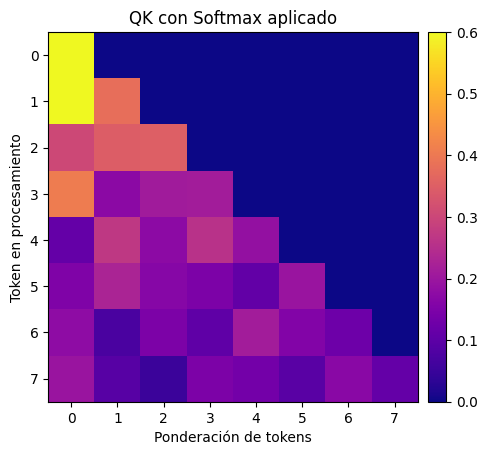

In [10]:
plt.imshow(attn[2].detach().squeeze(), vmin=0, vmax=0.6, cmap='plasma')
plt.gca().set(
    xlabel='Ponderación de tokens',
    ylabel='Token en procesamiento',
    title='QK con Softmax aplicado',
)
plt.colorbar(pad=0.02)
plt.show()

In [11]:
# Prueba de coherencia ;)
attn[2].detach().squeeze().sum(dim=1)

tensor([1., 1., 1., 1., 1., 1., 1., 1.])

## Texto Generado

In [12]:
# Comenzar con algunos tokens nuevos
text = 'When I grow up, I want to be a'
tokens = tokenizer.encode(text)
tokens = torch.tensor(tokens).unsqueeze(0)

generated_tokens = model.generate(tokens, temperature=2, n_new_tokens=10)[0]

# ¡Veamos cómo se ve!
tokenizer.decode(generated_tokens.tolist())

'When I grow up, I want to be a Carol Nguyen boutique throwscentered chromosMission装iOSablo'

In [13]:


# repeat with different temperature values

temps = [ .2, .7, 1, 2, 10 ] # outrageous values...

for T in temps:
  tokz = model.generate(tokens,temperature=T,n_new_tokens=10)
  tokz = tokz[0].tolist()
  print(f'Temp = {T}:\n  {tokenizer.decode(tokz)}\n')

Temp = 0.2:
  When I grow up, I want to be a Survival geo Lamaanaly--------------------------------------------------------115 morallyoras Techn 490

Temp = 0.7:
  When I grow up, I want to be a mine earthquakesurat fiercely Fast inadequ Rahmanqus ----Kings

Temp = 1:
  When I grow up, I want to be a depictingtaking338%),- buffet exercisingMis externalische

Temp = 2:
  When I grow up, I want to be aRepl newfound iOS ESL PruittTimes traveledowner indirect problematic

Temp = 10:
  When I grow up, I want to be a Milo reflection besideombsMED ladder LAW authentic abnorm Owl

